# 06 Biological Response

This notebook investigates the relationship between thermal processing, transport behavior, microenvironment evolution, and biological response.

The biological-response dataset extends the Kinetic Blueprint framework by connecting materials design variables to cellular outcomes.

## Research Question

How do processing-induced changes in transport behavior and microenvironment evolution influence biological response?

## Kinetic Blueprint Context

Previous analyses demonstrated:

Thermal Processing
↓
Phase Architecture
↓
Network Connectivity
↓
Transport Behavior
↓
Microenvironment Evolution

The present notebook extends this hierarchy by examining biological response.

The goal is to evaluate whether processing-induced control of transport behavior and microenvironment evolution can explain differences in cell viability.

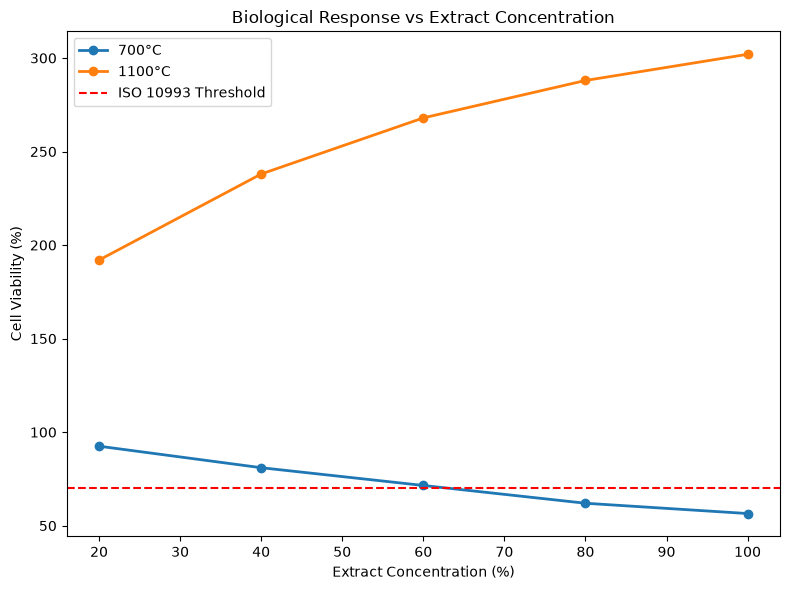

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_DIR = Path("..")
DATA_DIR = ROOT_DIR / "data"

bio_df = pd.read_csv(DATA_DIR / "biological_response.csv")

plt.figure(figsize=(8,6))

for temp in [700, 1100]:

    subset = bio_df[bio_df["Sintering_Temp_C"] == temp]

    mean_df = (
        subset.groupby("Extract_Percent")
        ["Cell_Viability_Percent"]
        .mean()
        .reset_index()
    )

    plt.plot(
        mean_df["Extract_Percent"],
        mean_df["Cell_Viability_Percent"],
        marker="o",
        linewidth=2,
        label=f"{temp}°C"
    )

plt.axhline(
    y=70,
    linestyle="--",
    color="red",
    label="ISO 10993 Threshold"
)

plt.xlabel("Extract Concentration (%)")
plt.ylabel("Cell Viability (%)")
plt.title("Biological Response vs Extract Concentration")

plt.legend()

plt.tight_layout()
plt.show()

## Biological Response Summary

The biological-response dataset evaluates how processing-induced changes in transport behavior and microenvironment evolution influence cellular outcomes.

Cell viability is interpreted using ISO 10993 criteria and provides a direct measure of biological performance.

In [2]:
summary_df = (
    bio_df.groupby(
        ["Sintering_Temp_C", "Extract_Percent"]
    )["Cell_Viability_Percent"]
    .agg(["mean", "std"])
    .reset_index()
)

summary_df

,Sintering_Temp_C,Extract_Percent,mean,std
0,700,20,92.5,1.479865
1,700,40,81.0,1.374773
2,700,60,71.5,1.473092
3,700,80,62.0,1.374773
4,700,100,56.5,1.609348
5,1100,20,192.0,2.913760
6,1100,40,238.0,2.905168
7,1100,60,268.0,3.360060
8,1100,80,288.0,3.278719
9,1100,100,302.0,3.800000


## Initial Interpretation

### 700 °C

- Cell viability decreases with increasing extract concentration.
- Cytotoxic behavior appears at high extract concentrations.
- Consistent with:
  - High NBO/BO ratio
  - High mass loss
  - High pH
  - Strong transport activity

### 1100 °C

- Cell viability increases dramatically with extract concentration.
- Strong proliferation response (~300% viability).
- Consistent with:
  - Controlled transport
  - Homeostatic microenvironment
  - Stable network architecture

## Microenvironment Regulation and Biological Response

### Scientific Motivation

Previous analyses demonstrated that transport behavior governs microenvironment evolution through changes in solution pH.

If microenvironment regulation influences cellular response, then materials producing different pH environments should exhibit distinct biological outcomes.

The following analysis evaluates the relationship between final solution pH and cell viability.

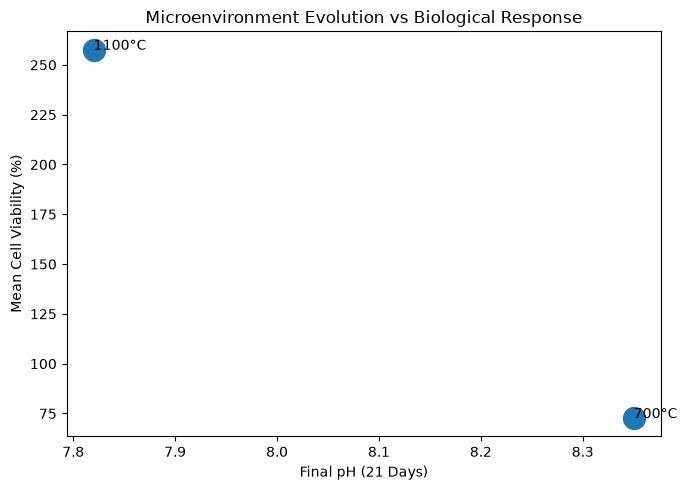

,Temperature_C,Final_pH_21d,Mean_Cell_Viability
0,700,8.35,72.7
1,1100,7.82,257.6


In [3]:
ph_df = pd.read_csv(DATA_DIR / "pH_time_series.csv")
final_pH = ph_df[ph_df["Time_Days"] == 21].set_index("Temperature_C")["pH_Value"]
final_pH_values = [final_pH[700], final_pH[1100]]

mean_viability = (
    bio_df.groupby("Sintering_Temp_C")
    ["Cell_Viability_Percent"]
    .mean()
    .reset_index()
)

bio_summary_df = pd.DataFrame({
    "Temperature_C": [700, 1100],
    "Final_pH_21d": final_pH_values,
    "Mean_Cell_Viability": [
        bio_df[bio_df["Sintering_Temp_C"] == 700]["Cell_Viability_Percent"].mean(),
        bio_df[bio_df["Sintering_Temp_C"] == 1100]["Cell_Viability_Percent"].mean()
    ]
})

plt.figure(figsize=(7,5))

plt.scatter(
    bio_summary_df["Final_pH_21d"],
    bio_summary_df["Mean_Cell_Viability"],
    s=250
)

for _, row in bio_summary_df.iterrows():
    plt.annotate(
        f"{int(row['Temperature_C'])}°C",
        (row["Final_pH_21d"], row["Mean_Cell_Viability"])
    )

plt.xlabel("Final pH (21 Days)")
plt.ylabel("Mean Cell Viability (%)")
plt.title("Microenvironment Evolution vs Biological Response")

plt.tight_layout()
plt.show()

bio_summary_df

## Interpretation

The biological-response dataset demonstrates that microenvironment evolution influences cellular outcomes.

### 700 °C

- Strong alkalization
- High transport activity
- Cytotoxic behavior at high extract concentrations

### 1100 °C

- Controlled alkalization
- Homeostatic microenvironment
- Strong cellular upregulation

These observations suggest that biological response emerges not only from composition but also from processing-induced control of transport behavior and microenvironment regulation.

This relationship represents the final stage of the Kinetic Blueprint framework.

## Kinetic Blueprint Biological Validation

### Scientific Synthesis

The biological-response dataset provides the final validation layer of the Kinetic Blueprint framework.

The combined analyses support the following deterministic pathway:

Thermal Processing
↓
Phase Architecture
↓
Network Connectivity
↓
Transport Behavior
↓
Microenvironment Evolution
↓
Biological Response

Key observations include:

- High NBO/BO ratios promote transport activity.
- Increased transport elevates solution pH.
- Strong alkalization is associated with reduced viability at high extract concentrations.
- Controlled transport produces a more stable microenvironment.
- Stable microenvironments support enhanced cellular response.

### Processing Extremes

#### 700 °C

- High transport activity
- Strong alkalization
- Cytotoxicity at high extract concentration

#### 1100 °C

- Controlled transport
- Homeostatic microenvironment
- Strong cellular upregulation (~300%)

These observations suggest that biological performance emerges from processing-induced control of structure, transport, and microenvironment evolution.

In [4]:
final_summary = pd.DataFrame({
    "Temperature_C": [700, 1100],
    "Final_pH": [8.35, 7.82],
    "Mean_Cell_Viability": [
        bio_df[bio_df["Sintering_Temp_C"] == 700]["Cell_Viability_Percent"].mean(),
        bio_df[bio_df["Sintering_Temp_C"] == 1100]["Cell_Viability_Percent"].mean()
    ]
})

final_summary

,Temperature_C,Final_pH,Mean_Cell_Viability
0,700,8.35,72.7
1,1100,7.82,257.6
